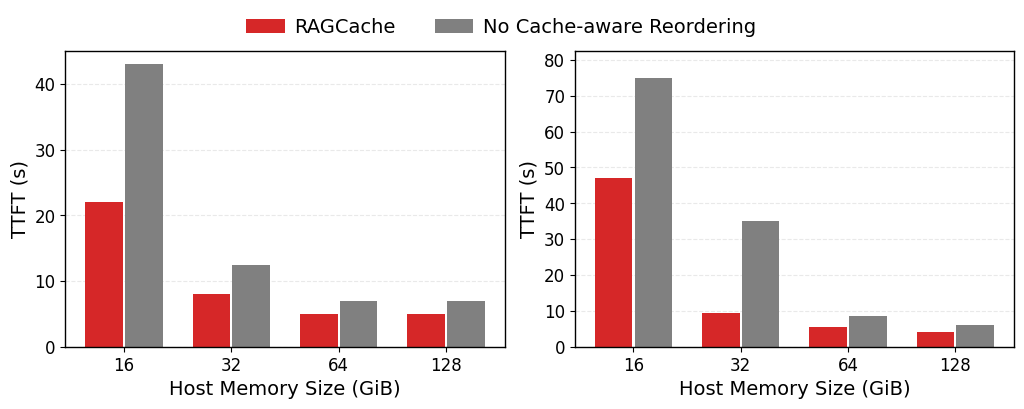

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 准备数据
host_memory_sizes_A = np.array([16, 32, 64, 128])
ragcache_ttft_A = np.array([22, 8, 5, 5])
no_cache_reorder_ttft_A = np.array([43, 12.5, 7, 7])

host_memory_sizes_B = np.array([16, 32, 64, 128])
ragcache_ttft_B = np.array([47, 9.5, 5.5, 4])
no_cache_reorder_ttft_B = np.array([75, 35, 8.5, 6])

# Common plotting parameters
bar_width = 0.35  # 每个条形图的宽度
group_spacing = 0.02 # 两组条形图之间的间隙，进一步减少

# X轴标签
labels = [f'{s}' for s in host_memory_sizes_A]

# 调整X轴位置，使每组条形图之间有间隙
r1 = np.arange(len(host_memory_sizes_A)) - (bar_width + group_spacing) / 2
r2 = np.arange(len(host_memory_sizes_A)) + (bar_width + group_spacing) / 2

# 颜色
color_ragcache = '#D62728'  # 红色
color_no_cache_reorder = '#808080' # 灰色

# 3. 创建图形和两个子图
# 子图长宽比为 5:3。
single_subplot_width = 5
single_subplot_height = 3
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(single_subplot_width * 2.2, single_subplot_height * 1.5), sharex=True)

# --- 绘制左图 (ax1) ---
ax1.bar(r1, ragcache_ttft_A, color=color_ragcache, width=bar_width, label='RAGCache')
ax1.bar(r2, no_cache_reorder_ttft_A, color=color_no_cache_reorder, width=bar_width, label='No Cache-aware Reordering')

# Customize ax1
ax1.set_ylabel('TTFT (s)', fontsize=14)
ax1.set_yticks(np.arange(0, 41, 10))
ax1.set_ylim(0, 45)
ax1.tick_params(axis='y', labelsize=12)
ax1.set_xticks(np.arange(len(host_memory_sizes_A)))
ax1.set_xticklabels(labels, fontsize=12)
ax1.set_xlabel('Host Memory Size (GiB)', fontsize=14)

# 网格线
ax1.grid(axis='y', linestyle='--', alpha=0.7, color='#E0E0E0')
ax1.set_axisbelow(True)

# 添加黑色边框
ax1.spines['top'].set_visible(True)
ax1.spines['right'].set_visible(True)
ax1.spines['left'].set_visible(True)
ax1.spines['bottom'].set_visible(True)
ax1.spines['top'].set_color('black')
ax1.spines['right'].set_color('black')
ax1.spines['left'].set_color('black')
ax1.spines['bottom'].set_color('black')
ax1.spines['top'].set_linewidth(1.0)
ax1.spines['right'].set_linewidth(1.0)
ax1.spines['left'].set_linewidth(1.0)
ax1.spines['bottom'].set_linewidth(1.0)

ax1.tick_params(axis='x', colors='black')
ax1.tick_params(axis='y', colors='black')


# --- 绘制右图 (ax2) ---
ax2.bar(r1, ragcache_ttft_B, color=color_ragcache, width=bar_width)
ax2.bar(r2, no_cache_reorder_ttft_B, color=color_no_cache_reorder, width=bar_width)

# Customize ax2
ax2.set_ylabel('TTFT (s)', fontsize=14)
max_y_B = max(ragcache_ttft_B.max(), no_cache_reorder_ttft_B.max())
ax2.set_yticks(np.arange(0, max_y_B + 10, 10))
ax2.set_ylim(0, max_y_B * 1.1)
ax2.tick_params(axis='y', labelsize=12)

ax2.set_xticks(np.arange(len(host_memory_sizes_B)))
ax2.set_xticklabels(labels, fontsize=12)
ax2.set_xlabel('Host Memory Size (GiB)', fontsize=14)

# 网格线
ax2.grid(axis='y', linestyle='--', alpha=0.7, color='#E0E0E0')
ax2.set_axisbelow(True)

# 添加黑色边框
ax2.spines['top'].set_visible(True)
ax2.spines['right'].set_visible(True)
ax2.spines['left'].set_visible(True)
ax2.spines['bottom'].set_visible(True)
ax2.spines['top'].set_color('black')
ax2.spines['right'].set_color('black')
ax2.spines['left'].set_color('black')
ax2.spines['bottom'].set_color('black')
ax2.spines['top'].set_linewidth(1.0)
ax2.spines['right'].set_linewidth(1.0)
ax2.spines['left'].set_linewidth(1.0)
ax2.spines['bottom'].set_linewidth(1.0)

ax2.tick_params(axis='x', colors='black')
ax2.tick_params(axis='y', colors='black')


# 共享图例（放置在两个子图的上方中心）
# 1. 图例不需要框： frameon=False
# 2. 图例的颜色和文字扩大：调整 fontsize，并可以使用 markerscale 来调整图例中颜色方块的大小
fig.legend(
    fontsize=14, # 增大字体大小
    loc='upper center',
    bbox_to_anchor=(0.5, 1.0), # 保持靠近上方
    ncol=2,
    frameon=False, # 移除图例边框
    handletextpad=0.5, # 图例符号和文字之间的间距
    columnspacing=2 # 图例列之间的间距
)

# 调整整体布局，减少空白
plt.tight_layout(rect=[0.04, 0.08, 0.98, 0.92]) # 微调 rect 参数，给图例留出空间，并减少顶部空白

# 显示图表
plt.savefig('ragcache.png', dpi=300, transparent=False, bbox_inches='tight')

plt.show()

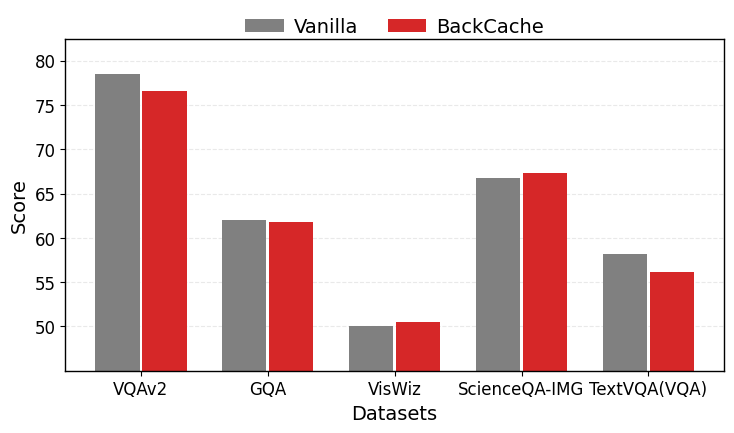

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 准备数据
datasets = ['VQAv2', 'GQA', 'VisWiz', 'ScienceQA-IMG', 'TextVQA(VQA)']
vanilla_scores = [78.5, 62, 50, 66.8, 58.2]
BackCache_scores = [76.59, 61.80, 50.48, 67.33, 56.10]

# 2. 设置绘图参数和颜色 (沿用之前的风格)
bar_width = 0.35 # 每个柱子的宽度
group_spacing = 0.02 # 同一组内两个柱子之间的间隙

# 颜色映射：BackCache 对应之前的 RAGCache 红色，Vanilla 对应灰色
color_BackCache = '#D62728' # 红色
color_vanilla = '#808080' # 灰色

# 图例标签
label_BackCache = 'BackCache'
label_vanilla = 'Vanilla'

# X轴刻度位置计算：确保两根柱子在X轴标签的中心
# r1 和 r2 是每组柱子左边缘的X坐标
r1 = np.arange(len(datasets)) - (bar_width + group_spacing) / 2
r2 = np.arange(len(datasets)) + (bar_width + group_spacing) / 2

# 3. 创建图形和单个子图
# 根据数据量和美观度，调整 figsize。这里尝试 (8, 5) 约为 1.6:1 的长宽比，适合单图
fig, ax = plt.subplots(figsize=(8, 5)) # 调整 figsize

# 4. 绘制柱形图
ax.bar(r1, vanilla_scores, color=color_vanilla, width=bar_width, label=label_vanilla)
ax.bar(r2, BackCache_scores, color=color_BackCache, width=bar_width, label=label_BackCache)

# 5. 自定义图表元素 (沿用之前的美学风格)

# Y轴标签和刻度
ax.set_ylabel('Score', fontsize=14) # Y轴标签改为 'Score'
# 动态计算Y轴范围和刻度，以适应数据
min_score = min(min(vanilla_scores), min(BackCache_scores))
max_score = max(max(vanilla_scores), max(BackCache_scores))
# 设置Y轴最小值略低于数据最小值，最大值略高于数据最大值
ax.set_ylim(min_score * 0.9, max_score * 1.05)
# 生成Y轴刻度：从向下取整到最近的5的倍数，到向上取整到最近的5的倍数，步长为5
y_ticks_interval = 5
ax.set_yticks(np.arange(np.floor(min_score / y_ticks_interval) * y_ticks_interval,
                         np.ceil(max_score / y_ticks_interval) * y_ticks_interval + y_ticks_interval,
                         y_ticks_interval))
ax.tick_params(axis='y', labelsize=12)

# X轴标签和刻度
ax.set_xlabel('Datasets', fontsize=14) # X轴标签改为 'Datasets'
ax.set_xticks(np.arange(len(datasets))) # X轴刻度位于每组柱子的中心
ax.set_xticklabels(datasets, fontsize=12, rotation=0) # X轴标签为数据集名称，不旋转

# 网格线
ax.grid(axis='y', linestyle='--', alpha=0.7, color='#E0E0E0')
ax.set_axisbelow(True) # 确保网格线在柱子下方

# 添加黑色边框 (针对单个子图)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_linewidth(1.0)
ax.spines['right'].set_linewidth(1.0)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

# 图例 (无框，颜色扩大，更靠近图表)
ax.legend(
    fontsize=14, # 增大字体大小
    loc='upper center', # 放置在图表上方中心
    bbox_to_anchor=(0.5, 1.12), # 微调Y坐标，使其更靠近图表内容
    ncol=2, # 分两列显示图例项
    frameon=False, # 不显示图例边框
    handletextpad=0.5, # 图例符号和文字之间的间距
    columnspacing=1.5 # 图例列之间的间距
)

# 调整整体布局，减少空白
# rect 参数用于调整子图在整个 figure 中的相对位置
# 减小底部和顶部边缘，为图例留出空间
plt.tight_layout(rect=[0.05, 0.05, 0.98, 0.95])

# 6. 保存图片到文件 (高清晰度)
# filename: 保存的文件名
# dpi: 每英寸点数，300 DPI 是出版物常见标准，600 DPI 更高
# transparent=False: 背景不透明
# bbox_inches='tight': 自动剪裁掉多余的空白边缘
plt.savefig('scores.png', dpi=300, transparent=False, bbox_inches='tight')

# 显示图表 (保存后依然可以显示)
plt.show()

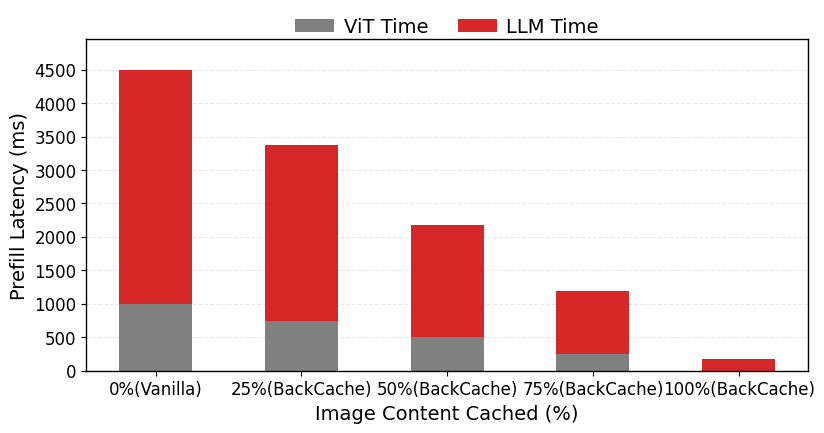

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 准备数据
# 顺序：Vanilla (0%), 25%, 50%, 75%, 100%
ordered_vit_time = np.array([1000, 750, 500, 250, 0])
ordered_llm_time = np.array([3500, 2625, 1680, 935, 175])

# 重新定义 X 轴标签以强调含义和新顺序
# 强调是“图片内容”的缓存命中比例
cache_labels = [
    '0%(Vanilla)',   # 明确表示Vanilla相当于0%命中
    '25%(Ours)',
    '50%(Ours)',
    '75%(Ours)',
    '100%(Ours)'
]

# 计算总时间
total_time = ordered_vit_time + ordered_llm_time

# 2. 设置绘图参数和颜色 (沿用之前的 RAGCache / No Cache 风格)
bar_width = 0.5
x_pos = np.arange(len(cache_labels))

# 颜色映射：LLM Time 红色，ViT Time 灰色
color_llm_time = '#D62728' # 红色
color_vit_time = '#808080' # 灰色

# 图例标签简化为：ViT Time 和 LLM Time
label_vit = 'ViT Time'
label_llm = 'LLM Time'

# 3. 创建图形和子图
fig, ax = plt.subplots(figsize=(9, 5))

# 4. 绘制堆叠柱形图
ax.bar(x_pos, ordered_vit_time, color=color_vit_time, width=bar_width, label=label_vit)
ax.bar(x_pos, ordered_llm_time, bottom=ordered_vit_time, color=color_llm_time, width=bar_width, label=label_llm)

# 5. 自定义图表元素 (沿用之前的美学风格)

# Y轴标签和刻度
ax.set_ylabel('Prefill Latency (ms)', fontsize=14)
max_total_time = total_time.max()
y_ticks_interval = 500
ax.set_yticks(np.arange(0, max_total_time * 1.1 + y_ticks_interval, y_ticks_interval))
ax.set_ylim(0, max_total_time * 1.1)
ax.tick_params(axis='y', labelsize=12)

# X轴标签和刻度 - 更改为更明确的语义
ax.set_xlabel('Image Content Cached (%)', fontsize=14) # 更明确的X轴标签
ax.set_xticks(x_pos)
ax.set_xticklabels(cache_labels, fontsize=12, rotation=0)

# 网格线
ax.grid(axis='y', linestyle='--', alpha=0.7, color='#E0E0E0')
ax.set_axisbelow(True)

# 添加黑色边框
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_linewidth(1.0)
ax.spines['right'].set_linewidth(1.0)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

# 图例 (无框，颜色扩大，更靠近图表，且标签简化)
ax.legend(
    fontsize=14,
    loc='upper center',
    bbox_to_anchor=(0.5, 1.12),
    ncol=2,
    frameon=False,
    handletextpad=0.5,
    columnspacing=1.5
)

# 调整整体布局，减少空白
plt.tight_layout(rect=[0.05, 0.05, 0.98, 0.95])

# 6. 保存图片到文件 (高清晰度)
plt.savefig('prefill_latency.png', dpi=300, transparent=False, bbox_inches='tight')

# 显示图表
plt.show()

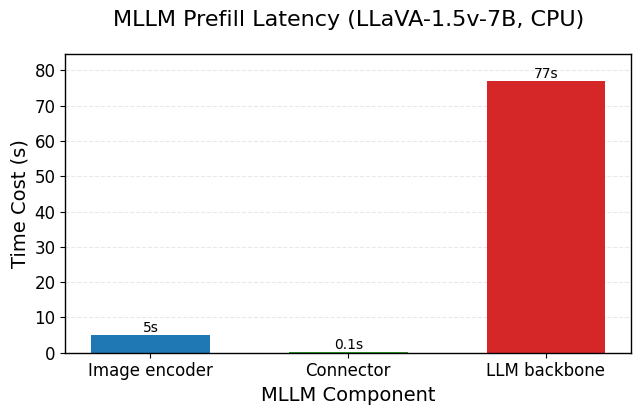

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Data
components = ['Image encoder', 'Connector', 'LLM backbone']
time_costs = np.array([5, 0.1, 77])

# 2. Plotting Parameters
bar_width = 0.6 # Width of each bar
x_pos = np.arange(len(components))

# Colors: Choose distinct colors for each component.
# Re-using the red for 'LLM backbone' to emphasize it as the bottleneck,
# and other distinct colors for the remaining components.
color_map = {
    'Image encoder': '#1f77b4',  # blue
    'Connector': '#2ca02c',     # green
    'LLM backbone': '#d62728'   # red (emphasizing bottleneck)
}
colors = [color_map[comp] for comp in components]

# 3. Create Figure and Subplot
fig, ax = plt.subplots(figsize=(7, 5)) # Adjusted figsize for a single plot

# 4. Plot Bars
# Directly plot each bar with its respective color
bars = ax.bar(x_pos, time_costs, width=bar_width, color=colors)

# 5. Customize Plot Elements (following previous style)

# Title for the plot
ax.set_title('MLLM Prefill Latency (LLaVA-1.5v-7B, CPU)', fontsize=16, pad=20) # Added a title

# Y-axis
ax.set_ylabel('Time Cost (s)', fontsize=14)
max_cost = time_costs.max()
# Set Y-ticks. Given 0.1, 5, 77, it's challenging to get perfect ticks for all.
y_ticks_interval = 10 # Step by 10s
ax.set_yticks(np.arange(0, max_cost + y_ticks_interval, y_ticks_interval))
ax.set_ylim(0, max_cost * 1.1) # Add 10% padding
ax.tick_params(axis='y', labelsize=12)

# X-axis
ax.set_xlabel('MLLM Component', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(components, fontsize=12, rotation=0) # Component names as labels

# Add value labels on top of bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height,
            f'{height:.1f}s' if height < 1 else f'{height:.0f}s', # Format small numbers with 1 decimal, large with 0
            ha='center', va='bottom', fontsize=10)

# Grid lines
ax.grid(axis='y', linestyle='--', alpha=0.7, color='#E0E0E0')
ax.set_axisbelow(True)

# Black borders
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.spines['left'].set_visible(True)
ax.spines['bottom'].set_visible(True)
ax.spines['top'].set_color('black')
ax.spines['right'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['top'].set_linewidth(1.0)
ax.spines['right'].set_linewidth(1.0)
ax.spines['left'].set_linewidth(1.0)
ax.spines['bottom'].set_linewidth(1.0)
ax.tick_params(axis='x', colors='black')
ax.tick_params(axis='y', colors='black')

# No legend needed for a single bar chart with values on top and clear X-axis labels.

# Adjust layout
plt.tight_layout(rect=[0.05, 0.05, 0.98, 0.9]) # Adjust rect to reduce whitespace, allow space for title

# 6. Save Plot
plt.savefig('bottlenecks.png', dpi=300, transparent=False, bbox_inches='tight')

# Display Plot
plt.show()

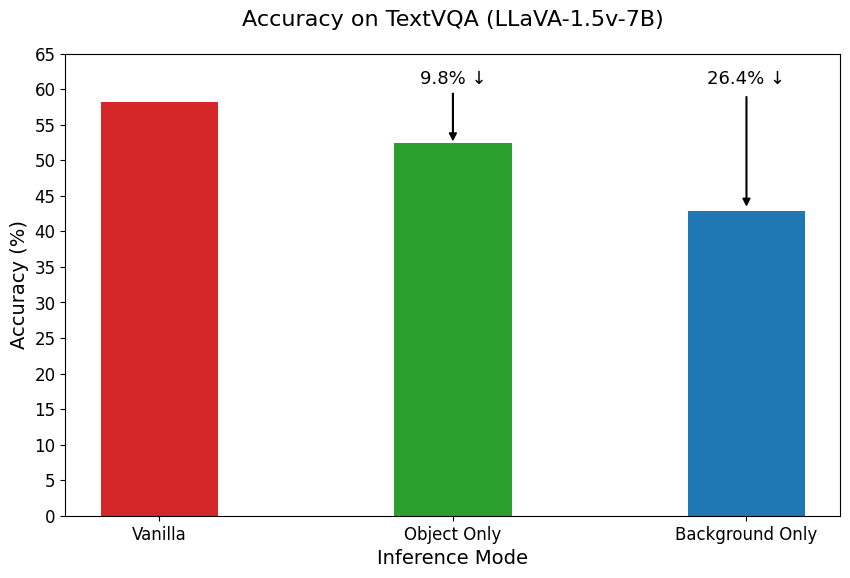

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 数据准备
inference_modes = ['Vanilla', 'Object Only', 'Background Only']
accuracy_scores = np.array([58.2, 52.49, 42.81])

# Calculate drops from Vanilla
vanilla_accuracy = accuracy_scores[0]
drop_from_vanilla = []
for i, score in enumerate(accuracy_scores):
    if i == 0:
        drop_from_vanilla.append(0.0) # Vanilla itself has no drop
    else:
        drop = ((vanilla_accuracy - score) / vanilla_accuracy) * 100
        drop_from_vanilla.append(drop)

# 2. 绘图参数设置
bar_width = 0.4 # 柱子宽度调整为更细
x_pos = np.arange(len(inference_modes))

# 颜色选择：为了与之前的绘图风格一致，并确保区分度
color_map = {
    'Vanilla': '#d62728',       # 红色 (作为基线，沿用之前LLM Time的强调色)
    'Object Only': '#2ca02c', # 绿色
    'Background Only': '#1f77b4'    # 蓝色
}
colors = [color_map[mode] for mode in inference_modes]

# 3. 创建图形和子图
fig, ax = plt.subplots(figsize=(10, 6)) # 调整 figsize

# 4. 绘制柱形图
bars = ax.bar(x_pos, accuracy_scores, width=bar_width, color=colors)

# 5. 自定义图表元素 (遵循之前的风格)

# 标题
ax.set_title('Accuracy on TextVQA (LLaVA-1.5v-7B)', fontsize=16, pad=20)

# Y轴
ax.set_ylabel('Accuracy (%)', fontsize=14)
min_acc = accuracy_scores.min()
max_acc = accuracy_scores.max()

# 动态设置Y轴范围，使其包含所有数据并留出一些空白
y_min_limit = 0 # 准确率通常从0开始
y_max_limit = max_acc * 1.1 if max_acc * 1.1 > 60 else 60 # 确保上限至少到60，以防最高值不高

ax.set_ylim(y_min_limit, y_max_limit)

# 设置Y轴刻度间隔
y_ticks_interval = 5
ax.set_yticks(np.arange(np.floor(y_min_limit / y_ticks_interval) * y_ticks_interval,
                                 np.ceil(y_max_limit / y_ticks_interval) * y_ticks_interval + y_ticks_interval,
                                 y_ticks_interval))
ax.tick_params(axis='y', labelsize=12)

# X轴
ax.set_xlabel('Inference Mode', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(inference_modes, fontsize=12, rotation=0)

# -----------------------------------------------------------------------------
# 关键修改：移除柱子上的绝对数值标签，只保留箭头和下降比例
# -----------------------------------------------------------------------------

# 绘制从 Vanilla 基线到下降点的箭头和文本
# 从第二个模式（Background Only）开始
for i in range(1, len(inference_modes)):
    current_x = x_pos[i]
    current_accuracy = accuracy_scores[i]
    drop_percentage = drop_from_vanilla[i]

    # 绘制从 Vanilla 高度到当前柱子顶部的垂直箭头
    # arrowprops 字典定义箭头的样式
    # 调整 xytext 的纵坐标，使其位于箭头上方，并确保箭头是垂直的
    ax.annotate(f'{drop_percentage:.1f}% ↓',
                xy=(current_x, current_accuracy), # 箭头指向的终点 (当前柱子顶部)
                xytext=(current_x, vanilla_accuracy + 2), # 箭头起始点 (Vanilla 准确率之上一点)
                xycoords='data',
                textcoords='data',
                arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=5, headlength=5), # 移除 connectionstyle，使用默认箭头样式
                ha='center', va='bottom', fontsize=13, color='black')

    # 绘制柱子

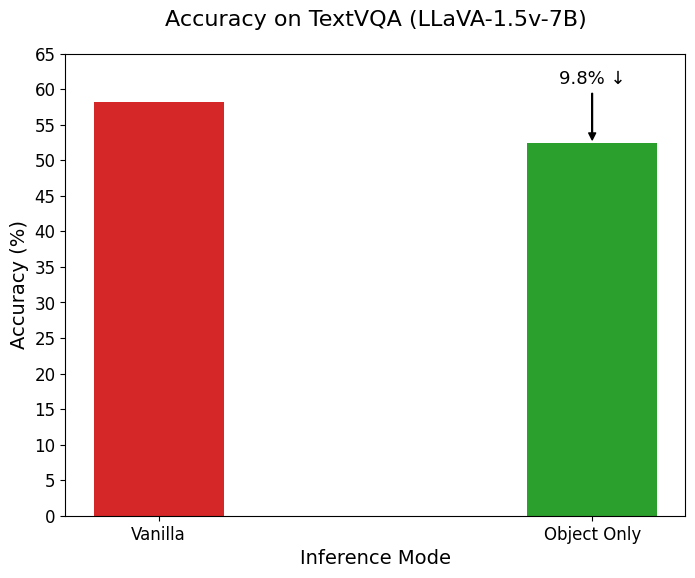

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 数据准备
inference_modes = ['Vanilla', 'Object Only']
accuracy_scores = np.array([58.2, 52.49])

# Calculate drops from Vanilla
vanilla_accuracy = accuracy_scores[0]
drop_from_vanilla = []
for i, score in enumerate(accuracy_scores):
    if i == 0:
        drop_from_vanilla.append(0.0) # Vanilla itself has no drop
    else:
        drop = ((vanilla_accuracy - score) / vanilla_accuracy) * 100
        drop_from_vanilla.append(drop)

# 2. 绘图参数设置
bar_width = 0.3 # 柱子宽度调整为更细
x_pos = np.arange(len(inference_modes))

# 颜色选择：为了与之前的绘图风格一致，并确保区分度
color_map = {
    'Vanilla': '#d62728',       # 红色 (作为基线，沿用之前LLM Time的强调色)
    'Object Only': '#2ca02c', # 绿色
    'Background Only': '#1f77b4'    # 蓝色
}
colors = [color_map[mode] for mode in inference_modes]

# 3. 创建图形和子图
fig, ax = plt.subplots(figsize=(8, 6)) # 调整 figsize

# 4. 绘制柱形图
bars = ax.bar(x_pos, accuracy_scores, width=bar_width, color=colors)

# 5. 自定义图表元素 (遵循之前的风格)

# 标题
ax.set_title('Accuracy on TextVQA (LLaVA-1.5v-7B)', fontsize=16, pad=20)

# Y轴
ax.set_ylabel('Accuracy (%)', fontsize=14)
min_acc = accuracy_scores.min()
max_acc = accuracy_scores.max()

# 动态设置Y轴范围，使其包含所有数据并留出一些空白
y_min_limit = 0 # 准确率通常从0开始
y_max_limit = max_acc * 1.1 if max_acc * 1.1 > 60 else 60 # 确保上限至少到60，以防最高值不高

ax.set_ylim(y_min_limit, y_max_limit)

# 设置Y轴刻度间隔
y_ticks_interval = 5
ax.set_yticks(np.arange(np.floor(y_min_limit / y_ticks_interval) * y_ticks_interval,
                                 np.ceil(y_max_limit / y_ticks_interval) * y_ticks_interval + y_ticks_interval,
                                 y_ticks_interval))
ax.tick_params(axis='y', labelsize=12)

# X轴
ax.set_xlabel('Inference Mode', fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(inference_modes, fontsize=12, rotation=0)

# -----------------------------------------------------------------------------
# 关键修改：移除柱子上的绝对数值标签，只保留箭头和下降比例
# -----------------------------------------------------------------------------

# 绘制从 Vanilla 基线到下降点的箭头和文本
# 从第二个模式（Background Only）开始
for i in range(1, len(inference_modes)):
    current_x = x_pos[i]
    current_accuracy = accuracy_scores[i]
    drop_percentage = drop_from_vanilla[i]

    # 绘制从 Vanilla 高度到当前柱子顶部的垂直箭头
    # arrowprops 字典定义箭头的样式
    # 调整 xytext 的纵坐标，使其位于箭头上方，并确保箭头是垂直的
    ax.annotate(f'{drop_percentage:.1f}% ↓',
                xy=(current_x, current_accuracy), # 箭头指向的终点 (当前柱子顶部)
                xytext=(current_x, vanilla_accuracy + 2), # 箭头起始点 (Vanilla 准确率之上一点)
                xycoords='data',
                textcoords='data',
                arrowprops=dict(facecolor='black', shrink=0.05, width=0.5, headwidth=5, headlength=5), # 移除 connectionstyle，使用默认箭头样式
                ha='center', va='bottom', fontsize=13, color='black')

    # 绘制柱子